In [1]:
import yaml

import matplotlib.pyplot as plt
from src.electrical_signature_frequencies import ANOMALY_FREQS

In [2]:
with open('../engine_configs/LIMAN.yml', 'r') as f:
    engine_config = yaml.safe_load(f)

# Processing Parameters
f_sampling = 10000
hop_length = 20
win_length = 40000
cutoff_freq = 250

file_label_map = {
    '../data/raw/0702 без перекосов фаза A.txt': 'normal',
    '../data/raw/0702  межвитковые фазы A ток фазы А.txt': 'inter-turn short circuits',
    '../data/raw/20_01_1460_об_мин_с_дисбалансом_ротора.txt': 'rotor bar defect'
}

fault_types_available = [
    'rotor bar defect',
    'inter-turn short circuits'
]

In [3]:
import numpy as np
from scipy.signal import ShortTimeFFT, get_window

def perform_stft(signal, f_sampling, win_length, hop_length, db=True, window='rectangular', cutoff_freq=250, mfft=None):
    """
    Perform a Short-Time Fourier Transform (STFT) on the input signal after removing its DC offset,
    and optionally use zero padding to improve the appearance of the frequency grid.

    This function subtracts the mean (DC offset) from the signal, applies the specified window
    (either a rectangular or a Hann window), and computes the STFT. A frequency cutoff is applied to 
    filter the spectrum, and the magnitudes are optionally converted to decibels.
    
    The nfft parameter specifies the number of points used in the FFT. If nfft is set larger than 
    the window length, zero padding is applied to refine the frequency grid. By default, if nfft is 
    not provided, it is set to the next power of 2 above the window length, which is efficient for FFT 
    computation and offers a denser frequency grid for improved peak localization.
    
    Parameters:
      signal      : 1D NumPy array, the time-domain input signal.
      f_sampling  : Sampling frequency.
      win_length  : Length (in samples) of the analysis window.
      hop_length  : Number of samples to advance the window on each step.
      db          : Boolean flag; if True, convert magnitudes to decibels.
      window      : String specifying the window type; 'hann' uses a Hann window, otherwise a rectangular window is used.
      cutoff_freq : Frequency cutoff (Hz) to filter the FFT result.
      mfft        : Number of FFT points. If None, nfft defaults to the next power of 2 above win_length.
    
    Returns:
      Sx   : 2D array of the STFT (time x frequency) after DC removal, possibly in dB scale.
      freqs: Frequency bins (filtered below cutoff_freq).
      times: Time instants corresponding to each FFT slice.
    """
    # Remove DC offset (mean subtraction) from the signal.
    signal = signal - np.mean(signal)
    
    # Choose an analysis window
    if window == 'hann':
        window_values = get_window('hann', win_length, fftbins=True)
    elif window == 'rectangular':
        window_values = np.ones(win_length)
    else:
        raise ValueError("Invalid window type; use 'hann' or 'rectangular'.")
    
    # Select mfft: if not provided, choose the next power of 2 above win_length.
    if mfft is None:
        mfft = int(2 ** np.ceil(np.log2(win_length)))
    
    # Create a ShortTimeFFT object.
    SFT = ShortTimeFFT(window_values, hop=hop_length, fs=f_sampling, scale_to=None, mfft=mfft)
    
    # Compute the STFT of the zero-mean signal.
    Sx = SFT.stft(signal)
    
    # Get frequency bins and time instants.
    freqs = SFT.f  # Frequency axis values (with spacing f_sampling/nfft)
    times = SFT.t(len(signal))  # Time instants for each FFT slice
    
    # Apply the frequency cutoff.
    cutoff_mask = freqs < cutoff_freq
    Sx = Sx[cutoff_mask, :]
    freqs = freqs[cutoff_mask]
    
    # Optionally, convert the magnitude spectrum to decibels.
    if db:
        epsilon = 1e-12  # to avoid log(0)
        Sx = 20 * np.log10(np.abs(Sx) + epsilon)
    
    # Transpose Sx so that rows correspond to time and columns to frequency bins.
    return Sx.T, freqs, times

In [4]:
from src.data_pipeline import (
    read_oscilloscope_data,
    normalize_segment
)

label_file_map = {v: k for k, v in file_label_map.items()}
label_segs_map = {}


for v, k in label_file_map.items():
    data = read_oscilloscope_data(k, output_path=None)['Data'].values
    label_segs_map[v], freqs, times = perform_stft(data, f_sampling, win_length, hop_length, window='hann', db=True, cutoff_freq=250)
    label_segs_map[v] = np.array([normalize_segment(seg, method='min-max')[0] for seg in label_segs_map[v]])

In [5]:
def get_average_spectrum(segs):
    return np.mean(segs, axis=0)

def get_spectrum_std(segs):
    return np.std(segs, axis=0)

def plot_average_spectrum(ax, segs, freqs, label='Average Spectrum'):
    avg_spectrum = get_average_spectrum(segs)

    ax.plot(freqs, avg_spectrum, linewidth=2.0, color='blue', label=label)
    return ax

def plot_spectrum_std(ax, segs, freqs, n_std=3):
    avg_spectrum = get_average_spectrum(segs)
    spectrum_std = get_spectrum_std(segs)

    ax.fill_between(
        freqs,
        avg_spectrum - spectrum_std,
        avg_spectrum + spectrum_std,
        color='blue',
        alpha=0.2,
        label=f'Uncertainty (±{n_std} SD)'
    )
    # Add thicker boundary lines for the shaded region
    ax.plot(freqs, avg_spectrum - spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    ax.plot(freqs, avg_spectrum + spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    return ax

def draw_signature_lines(ax, freqs):
        for freq in freqs:
            if freq > 0:
                ax.axvline(x=freq, color='red', linestyle='--', linewidth=1.0)


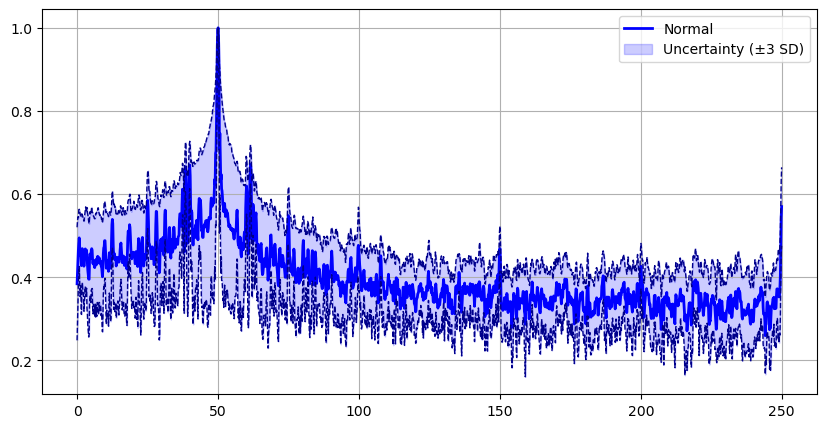

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_average_spectrum(ax, label_segs_map['normal'], freqs, label='Normal')
plot_spectrum_std(ax, label_segs_map['normal'], freqs, n_std=3)
plt.legend()
plt.grid()
plt.show()

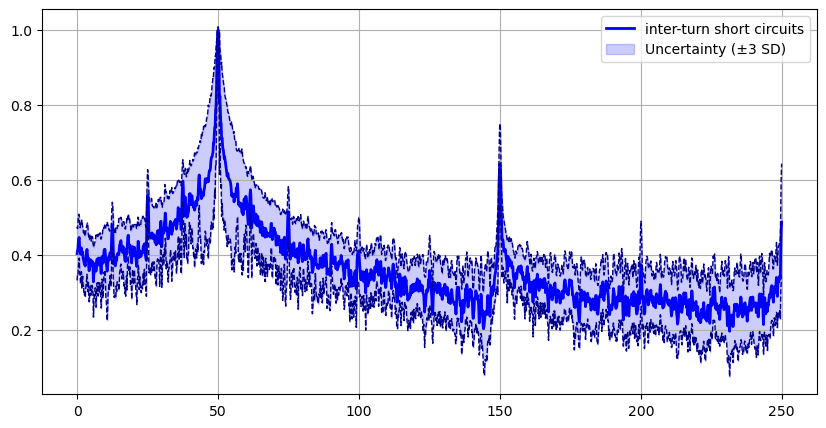

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_average_spectrum(ax, label_segs_map['inter-turn short circuits'], freqs, label='inter-turn short circuits')
plot_spectrum_std(ax, label_segs_map['inter-turn short circuits'], freqs, n_std=3)
plt.legend()
plt.grid()
plt.show()

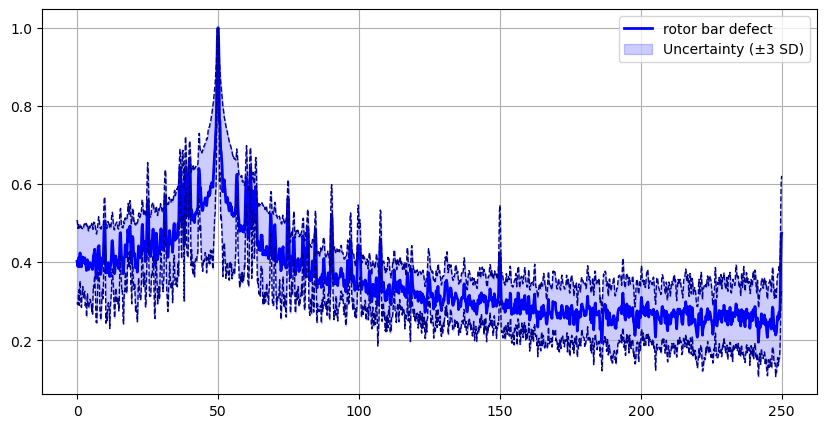

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_average_spectrum(ax, label_segs_map['rotor bar defect'], freqs, label='rotor bar defect')
plot_spectrum_std(ax, label_segs_map['rotor bar defect'], freqs, n_std=3)
plt.grid()
plt.legend()
plt.show()

## Deltas

In [9]:
normal_segs = label_segs_map['normal']
itsc_segs = label_segs_map['inter-turn short circuits']
rbd_segs = label_segs_map['rotor bar defect']

In [10]:
delta_itsc = itsc_segs - normal_segs[:itsc_segs.shape[0], :]
delta_rbd = rbd_segs - normal_segs[:rbd_segs.shape[0], :]

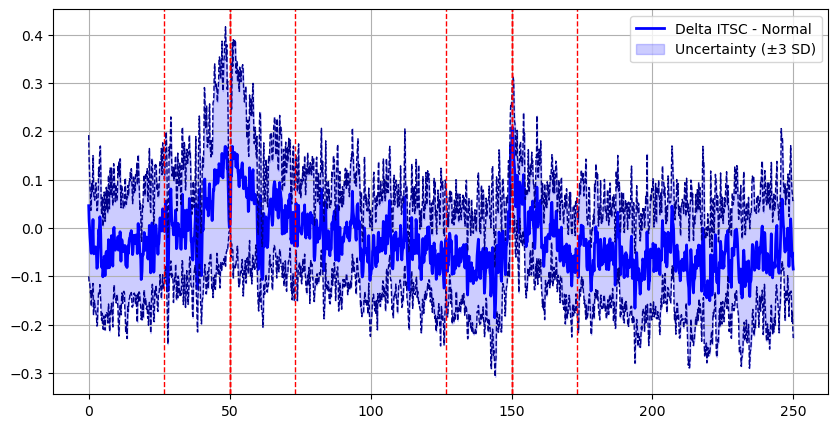

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

fault_freqs = ANOMALY_FREQS.get('inter-turn short circuits', lambda ec: [])(engine_config)
plot_average_spectrum(ax, delta_itsc, freqs, label='Delta ITSC - Normal')
plot_spectrum_std(ax, delta_itsc, freqs, n_std=3)
draw_signature_lines(ax, fault_freqs)
plt.legend()
plt.grid()
plt.show()

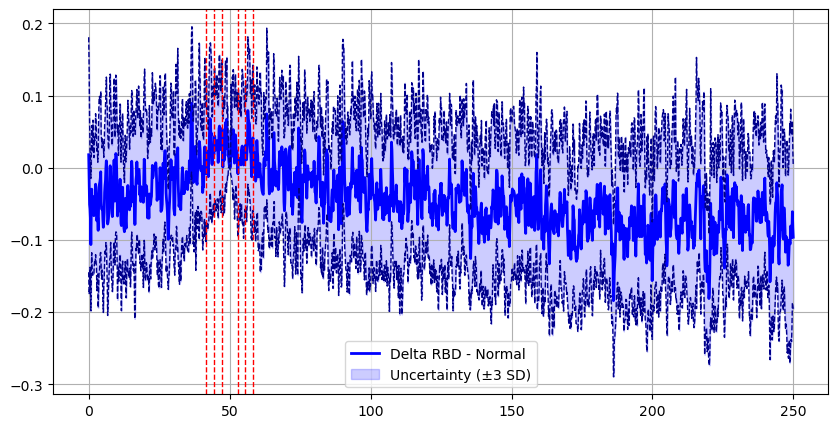

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))


fault_freqs = ANOMALY_FREQS.get('rotor bar defect', lambda ec: [])(engine_config)
plot_average_spectrum(ax, delta_rbd, freqs, label='Delta RBD - Normal')
plot_spectrum_std(ax, delta_rbd, freqs, n_std=3)
draw_signature_lines(ax, fault_freqs)
plt.legend()
plt.grid()
plt.show()